In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [34]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Number of rows and columns:
(3000888, 6)

Column names:
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 196.8 MB


In [35]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [36]:
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [37]:
df['date'] = pd.to_datetime(df['date'])

print(df['date'].head())

0   2013-01-01
1   2013-01-01
2   2013-01-01
3   2013-01-01
4   2013-01-01
Name: date, dtype: datetime64[us]


In [38]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

df.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1


In [39]:
daily_sales = df.groupby('date')['sales'].sum().reset_index()

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


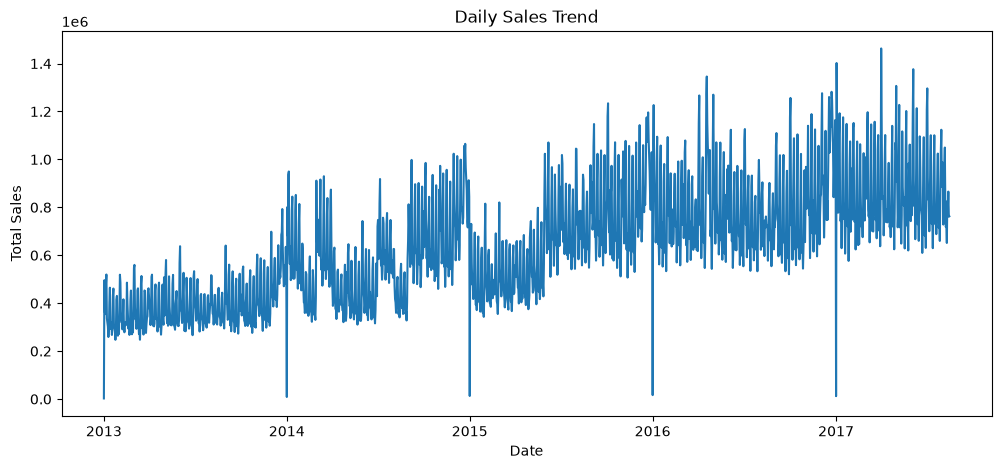

In [40]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales['date'], daily_sales['sales'])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

In [41]:
monthly_sales = df.groupby(['year', 'month'])['sales'].sum().reset_index()

monthly_sales.head()

,year,month,sales
0,2013,1,1.032762e+07
1,2013,2,9.658960e+06
2,2013,3,1.142850e+07
3,2013,4,1.099346e+07
4,2013,5,1.159770e+07


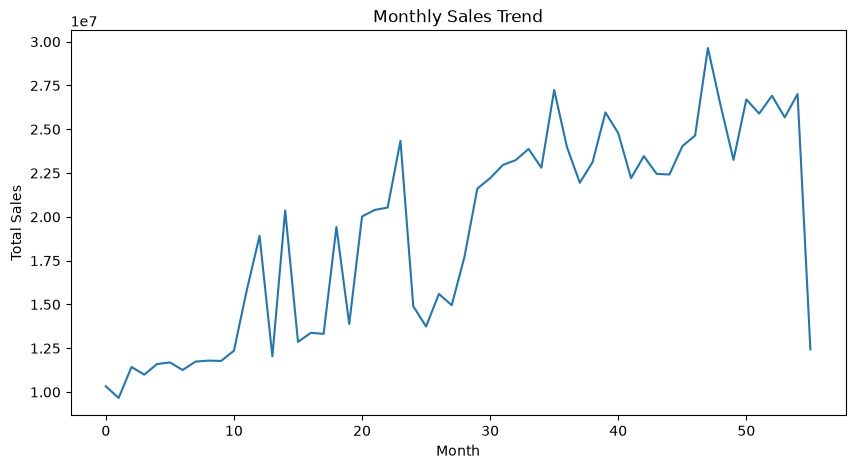

In [42]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index, monthly_sales['sales'])

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

In [43]:
daily_sales['date_number'] = (
    daily_sales['date'] - daily_sales['date'].min()
).dt.days

daily_sales.head()

,date,sales,date_number
0,2013-01-01,2511.618999,0
1,2013-01-02,496092.417944,1
2,2013-01-03,361461.231124,2
3,2013-01-04,354459.677093,3
4,2013-01-05,477350.121229,4


In [44]:
split = int(len(daily_sales) * 0.8)

train = daily_sales[:split]
test = daily_sales[split:]

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 1347
Testing data: 337


In [45]:
X_train = train[['date_number']]
y_train = train['sales']

X_test = test[['date_number']]
y_test = test['sales']

In [46]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [47]:
predictions = model.predict(X_test)

print("Predicted sales:")
print(predictions[:10])

Predicted sales:
[841413.71803827 841793.33961864 842172.96119901 842552.58277938
 842932.20435974 843311.82594011 843691.44752048 844071.06910085
 844450.69068122 844830.31226159]


In [48]:
result = pd.DataFrame({
    'Date': test['date'],
    'Actual Sales': y_test,
    'Predicted Sales': predictions
})

result.head(10)

,Date,Actual Sales,Predicted Sales
1347,2016-09-12,6.787765e+05,841413.718038
1348,2016-09-13,6.034279e+05,841793.339619
1349,2016-09-14,6.242621e+05,842172.961199
1350,2016-09-15,5.683248e+05,842552.582779
1351,2016-09-16,6.919126e+05,842932.204360
1352,2016-09-17,8.992193e+05,843311.825940
1353,2016-09-18,1.018663e+06,843691.447520
1354,2016-09-19,6.811593e+05,844071.069101
1355,2016-09-20,6.509803e+05,844450.690681
1356,2016-09-21,6.669284e+05,844830.312262


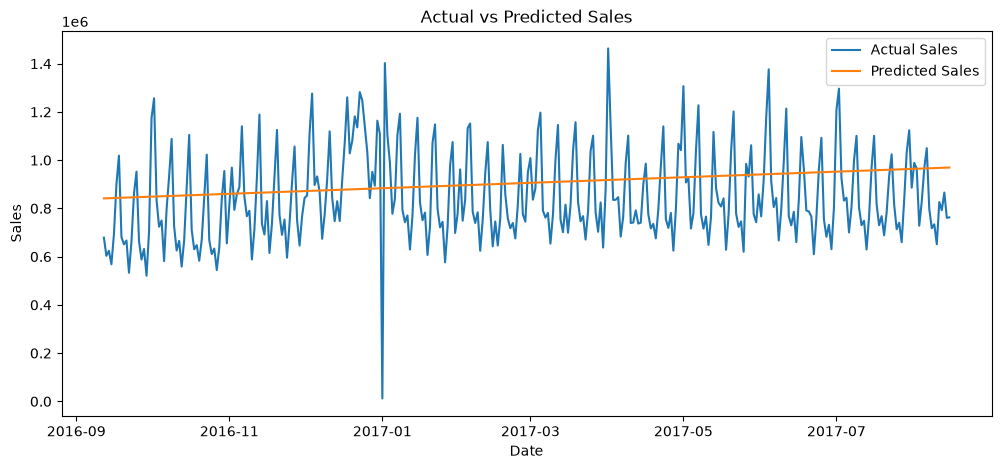

In [49]:
plt.figure(figsize=(12,5))

plt.plot(test['date'], y_test, label='Actual Sales')
plt.plot(test['date'], predictions, label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [50]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 166276.574127357
RMSE: 194319.64056985374
R2 Score: -0.0955887351156739


In [51]:
future_days = 30

last_day = daily_sales['date_number'].max()

future = pd.DataFrame({
    'date_number': range(
        last_day + 1,
        last_day + future_days + 1
    )
})

future['predicted_sales'] = model.predict(
    future[['date_number']]
)

future['date'] = pd.date_range(
    start=daily_sales['date'].max() + pd.Timedelta(days=1),
    periods=future_days
)

future.head()

,date_number,predicted_sales,date
0,1688,969725.812203,2017-08-16
1,1689,970105.433783,2017-08-17
2,1690,970485.055364,2017-08-18
3,1691,970864.676944,2017-08-19
4,1692,971244.298524,2017-08-20


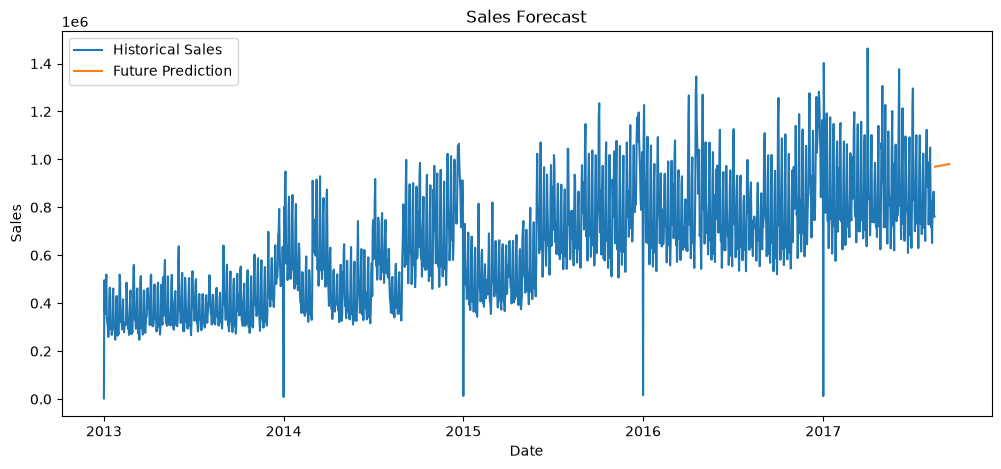

In [52]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales['date'],
    daily_sales['sales'],
    label='Historical Sales'
)

plt.plot(
    future['date'],
    future['predicted_sales'],
    label='Future Prediction'
)

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.show()